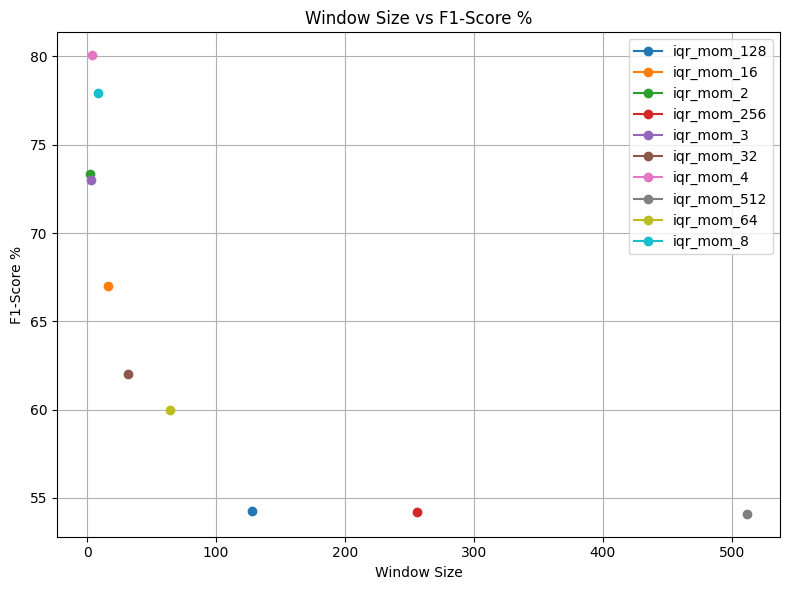

In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
 
# ==========================================================
# 1. Directory containing result files
# ==========================================================
results_dir = "c:/Users/Rayaan_Ghosh/Desktop/OSS/cp219_project-2/src/collaboration/Final_Results_4_Feb_copy/Final_Results_4_Feb_copy/Codes_And_Results/all_plots_data/Algorithm_wise_plots_data/"
 
# ==========================================================
# 2. Load all relevant CSV files
# ==========================================================
pattern = os.path.join(results_dir, "iqr_mom*_metrics_long.csv")
files = glob.glob(pattern)
 
all_dfs = []
 
for file in files:
    df = pd.read_csv(file)
 
    # Extract window size from filename
    filename = os.path.basename(file)
    match = re.search(r'iqr_mom_(\d+)_metrics_long', filename)
 
    if match:
        window_size = int(match.group(1))
    else:
        # fallback for file without explicit size
        window_size = None
 
    df["WindowSize"] = window_size
    all_dfs.append(df)
 
# Combine all files
combined_df = pd.concat(all_dfs, ignore_index=True)
 
# ==========================================================
# 3. Group by Algorithm and Window Size
# ==========================================================
grouped = (
    combined_df
    .groupby(["Algorithm", "WindowSize"], as_index=False)
    .mean(numeric_only=True)
)
 
# ==========================================================
# 4. Plot Window Size vs F1-Score %
# ==========================================================
plt.figure(figsize=(8, 6))
 
for algo in grouped["Algorithm"].unique():
    algo_df = grouped[grouped["Algorithm"] == algo].sort_values("WindowSize")
    
    plt.plot(
        algo_df["WindowSize"],
        algo_df["F1-Score %"],
        marker='o',
        label=algo
    )
 
plt.xlabel("Window Size")
plt.ylabel("F1-Score %")
plt.title("Window Size vs F1-Score %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
 

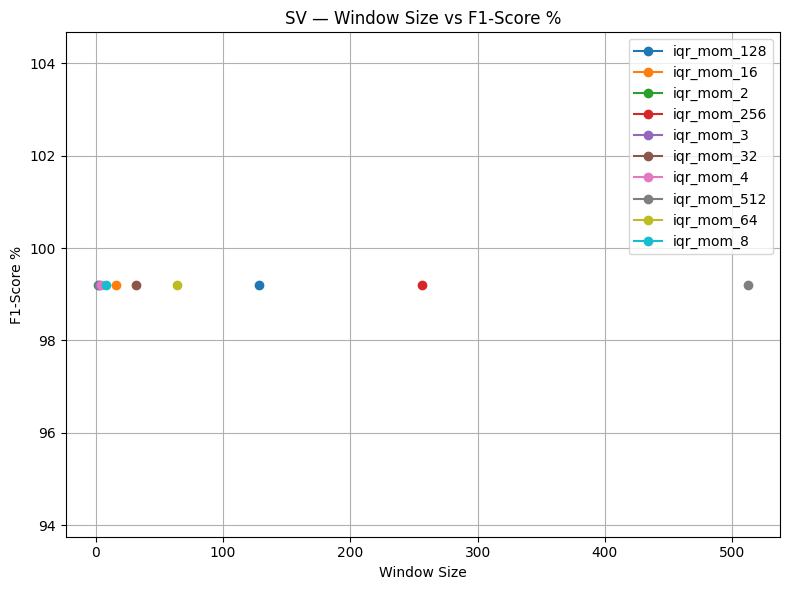

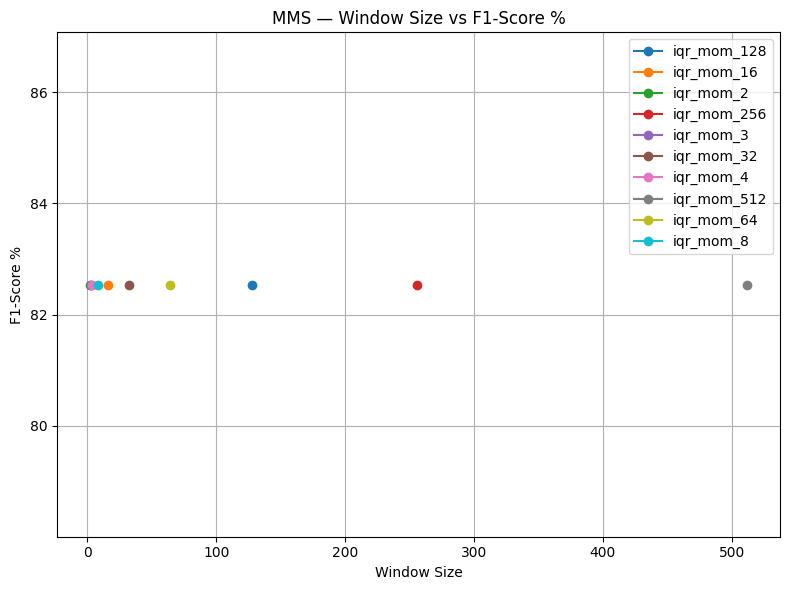

In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. Directory containing result files
# ==========================================================
results_dir = "c:/Users/Rayaan_Ghosh/Desktop/OSS/cp219_project-2/src/collaboration/Final_Results_4_Feb_copy/Final_Results_4_Feb_copy/Codes_And_Results/all_plots_data/Algorithm_wise_plots_data/"

# ==========================================================
# 2. Load all relevant CSV files
# ==========================================================
pattern = os.path.join(results_dir, "iqr_mom*_metrics_long.csv")
files = glob.glob(pattern)

all_dfs = []

for file in files:
    df = pd.read_csv(file)

    # Extract window size from filename
    filename = os.path.basename(file)
    match = re.search(r'iqr_mom_(\d+)_metrics_long', filename)

    if match:
        window_size = int(match.group(1))
    else:
        window_size = None

    df["WindowSize"] = window_size
    all_dfs.append(df)

# Combine all files
combined_df = pd.concat(all_dfs, ignore_index=True)

# ==========================================================
# 3. Plot for each dataset: SV and MMS
# ==========================================================
for dataset_name in ["SV", "MMS"]:
    dataset_df = combined_df[combined_df["Dataset"] == dataset_name]

    if dataset_df.empty:
        print(f"No data found for dataset: {dataset_name}")
        continue

    grouped = (
        dataset_df
        .groupby(["Algorithm", "WindowSize"], as_index=False)
        .mean(numeric_only=True)
    )

    plt.figure(figsize=(8, 6))

    for algo in grouped["Algorithm"].unique():
        algo_df = grouped[grouped["Algorithm"] == algo].sort_values("WindowSize")
        plt.plot(
            algo_df["WindowSize"],
            algo_df["F1-Score %"],
            marker='o',
            label=algo
        )

    plt.xlabel("Window Size")
    plt.ylabel("F1-Score %")
    plt.title(f"{dataset_name} — Window Size vs F1-Score %")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()